In [7]:
%matplotlib inline
import matplotlib as mpl
from matplotlib import pyplot as plt
import matplotlib.patheffects as path_effects
from matplotlib.collections import LineCollection
from matplotlib.patches import Rectangle,ConnectionPatch
from matplotlib.gridspec import GridSpec
import pandas as pd
typeface='Helvetica Neue'
mpl.rcParams['font.weight']=300
mpl.rcParams['axes.labelweight']=300
mpl.rcParams['font.family']=typeface
mpl.rcParams['font.size']=22
mpl.rcParams['pdf.fonttype']=42

import os,glob
import numpy as np
import baltic as bt
import json


Tree height: 0.153823
Tree length: 3.984874
annotations present

Numbers of objects in tree: 7649 (3381 nodes and 4268 leaves)

['Rest of South America' 'Asia' 'Africa' 'Colombia'
 'North America & the Caribbean' 'Europe']


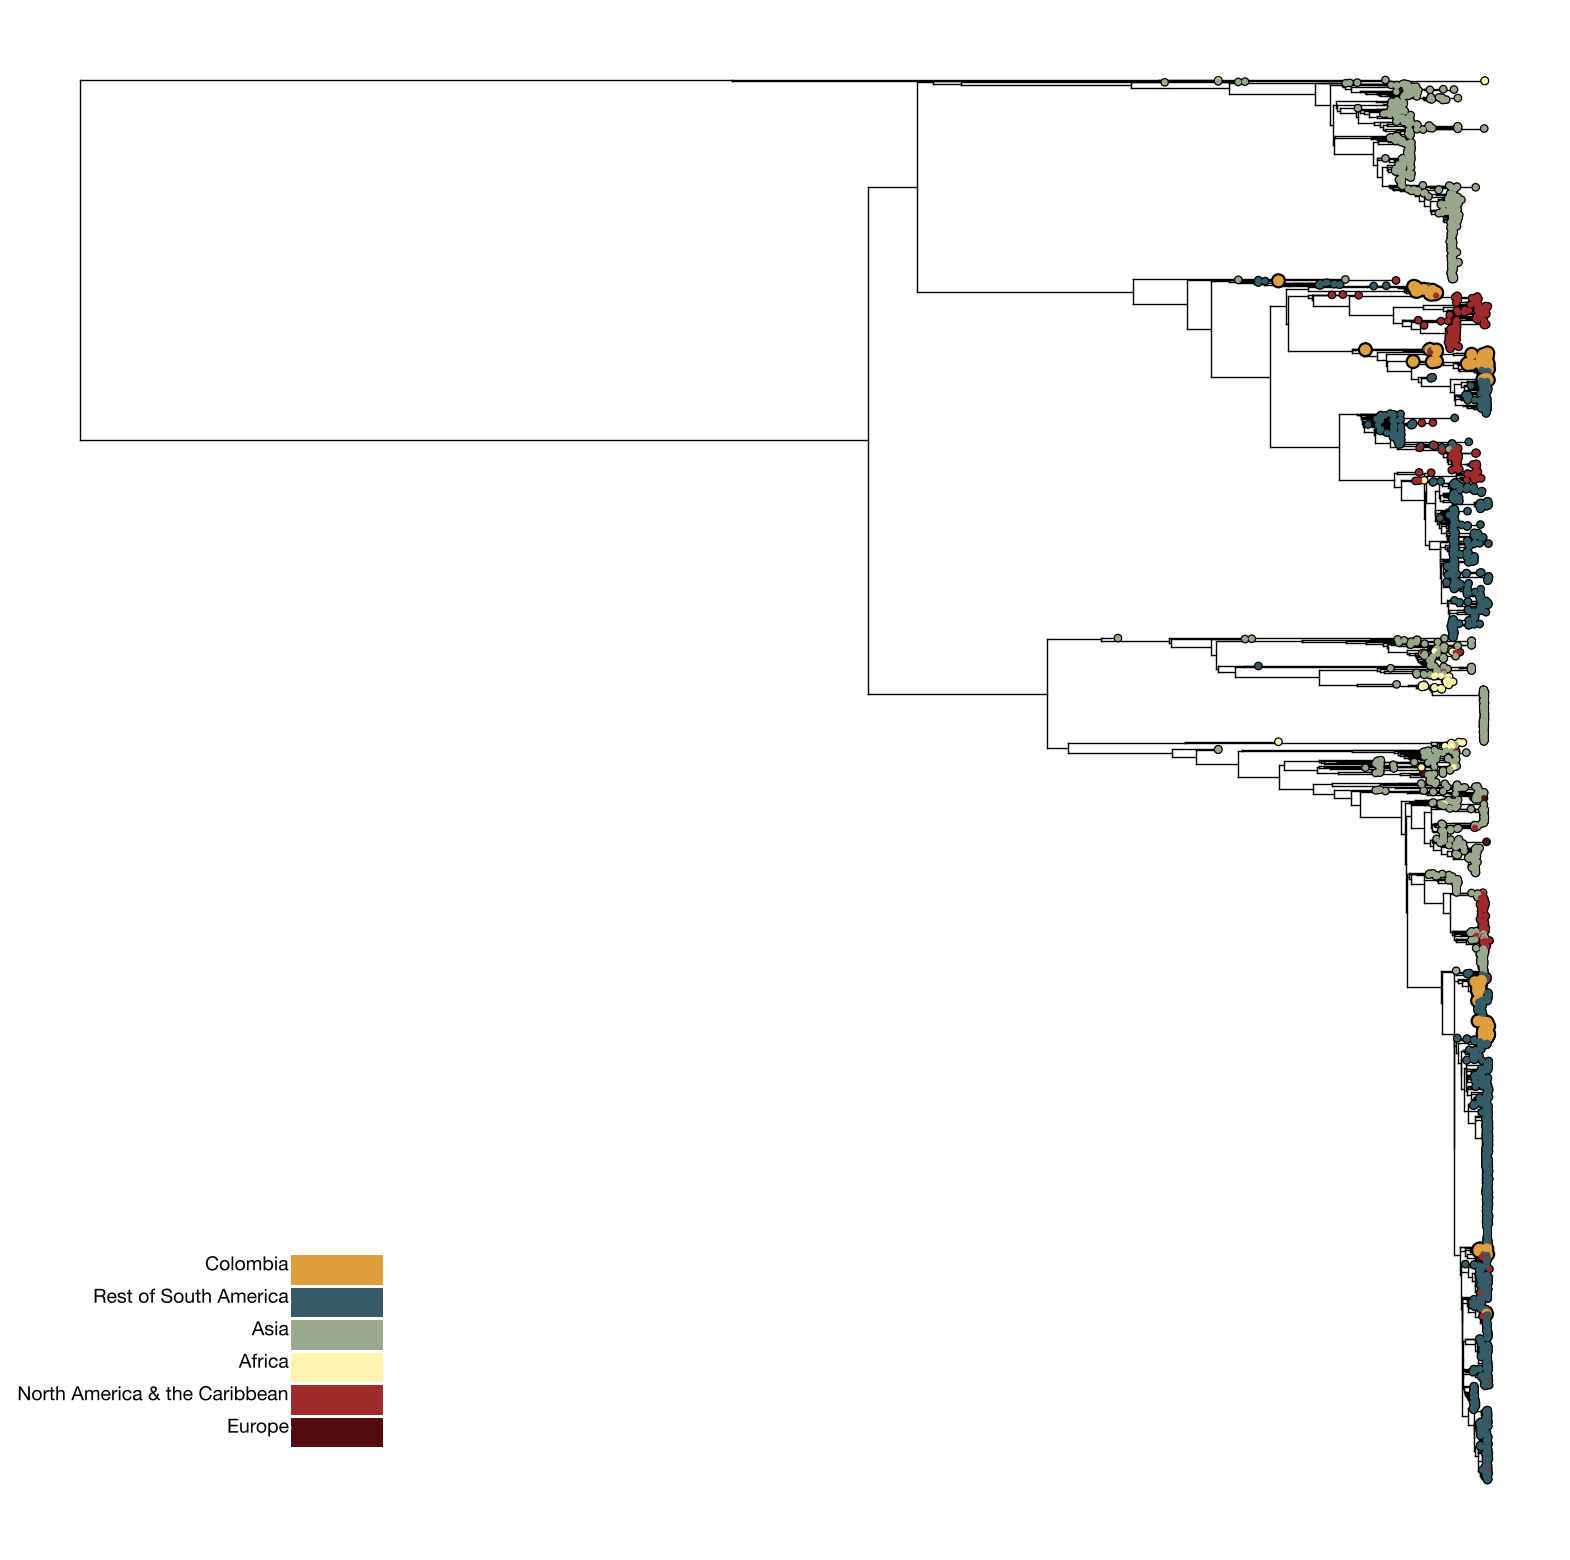

In [80]:
treePath = '/Users/ricardorivero/Documents/DENV/Global_aln/Timetree/global_timetree.nwk'
ll = bt.loadNewick(treePath, tip_regex='\|([0-9]+\-[0-9]+\-[0-9]+)',date_fmt='%Y-%m-%d',variableDate=True,absoluteTime=True,verbose=False, sortBranches = True)
ll.setAbsoluteTime(2024.563)
ll.treeStats()
# load metadata
metaPath = '/Users/ricardorivero/Documents/DENV/Global_aln/metadata/global_metadata_d2.tsv'
meta = pd.read_csv(metaPath,sep='\t')

#assign metadata to tree
for k in ll.Objects:
    if k.is_leaf():
        if k.name in meta['strain'].values:
            k.traits['location'] = meta.loc[meta['strain']==k.name,'location'].values[0]

print(meta['location'].unique())

colors = {'Rest of South America':'#335c67', 'Asia': '#99a88c', 'Africa': '#fff3b0', 'Colombia':'#e09f3e', 'North America & the Caribbean': '#9e2a2b', 'Europe':'#540b0e'}
c_func = lambda k: colors[k.traits['location']] if 'location' in k.traits and k.traits['location'] in colors else '#FFCD00'
s_func = lambda k: 60 if k.traits['location'] == 'Colombia' else 20

fig, ax = plt.subplots(figsize=(20, 20), facecolor='w')

ll.plotTree(ax, x_attr=lambda k: k.absoluteTime, colour='k', width=1)
ll.plotPoints(ax, x_attr=lambda k: k.absoluteTime, colour=c_func, size=s_func, zorder=1000)


#legend

h=90
w=0.01


for c,location in enumerate(['Colombia','Rest of South America', 'Asia', 'Africa','North America & the Caribbean', 'Europe'][::-1]): ## iterate over specific countries
    x=2024.433## where legend patch starts horizontally
    y=100+c*h*1.1 ## where legend patch starts vertically
    fc=colors[location] ## get colour
    
    effects=[path_effects.Stroke(linewidth=4, foreground='white'),
             path_effects.Stroke(linewidth=0, foreground='k')] ## black text, white outline
    
    ax.add_patch(Rectangle((x,y),w,h,facecolor=fc,edgecolor='none',clip_on=False)) ## add coloured legend patch
    ax.text(x-w*0.02,y+h/1.5,location,color='k',size=14,va='center',ha='right',path_effects=effects,zorder=100) ## label legend patch

[ax.spines[loc].set_visible(False) for loc in ['top', 'right', 'left', 'bottom']]
ax.set_yticks([]) 
ax.set_yticklabels([])
ax.set_xticks([]) 
ax.set_xticklabels([])

[ax.axvspan(x,x+10,fc='k',ec='none',alpha=0.05,zorder=0) for x in range(1959,2024,20) if x%5==0]

resolutionValue = 1200
plt.savefig('/Users/ricardorivero/Documents/DENV/Global_aln/globalTree.svg', dpi=resolutionValue, bbox_inches='tight', format='svg')
plt.savefig('/Users/ricardorivero/Documents/DENV/Global_aln/globalTree.jpeg', dpi=resolutionValue, bbox_inches='tight', format='jpeg')
plt.show()